In [4]:
import pandas as pd
import matplotlib.pyplot as plt

Task 1: Data Loading & Understanding

In [9]:
file = "phonepe-pulse_raw-data.xlsx"
state_txn = pd.read_excel(file, sheet_name="State_Txn and Users")
state_txn_split = pd.read_excel(file, sheet_name="State_TxnSplit")
state_device = pd.read_excel(file, sheet_name="State_DeviceData")
district_txn = pd.read_excel(file, sheet_name="District_Txn and Users")
district_demo = pd.read_excel(file, sheet_name="District Demographics")


In [10]:
print(state_txn.head())
print(state_txn_split.head())
print(state_device.head())
print(district_txn.head())
print(district_demo.head())

                       State  Year  Quarter  Transactions  Amount (INR)  \
0  Andaman & Nicobar Islands  2018        1          6658  1.463176e+07   
1  Andaman & Nicobar Islands  2018        2         11340  2.833854e+07   
2  Andaman & Nicobar Islands  2018        3         16265  5.555747e+07   
3  Andaman & Nicobar Islands  2018        4         23758  9.054834e+07   
4  Andaman & Nicobar Islands  2019        1         30486  1.022997e+08   

     ATV (INR)  Registered Users  App Opens  
0  2197.621091              6740          0  
1  2498.989022              9405          0  
2  3415.768284             12149          0  
3  3811.277720             15222          0  
4  3355.630147             18596          0  
                       State  Year  Quarter          Transaction Type  \
0  Andaman & Nicobar Islands  2018        1  Recharge & bill payments   
1  Andaman & Nicobar Islands  2018        1     Peer-to-peer payments   
2  Andaman & Nicobar Islands  2018        1         Me

1.2 Display Basic Statisticsbasic and Data types

In [11]:
print(state_txn.describe())
print(state_txn.dtypes)

              Year     Quarter  Transactions  Amount (INR)    ATV (INR)  \
count   504.000000  504.000000  5.040000e+02  5.030000e+02   504.000000   
mean   2019.285714    2.357143  4.074000e+07  7.083332e+10  1993.471543   
std       1.031181    1.109971  8.228714e+07  1.440902e+11   607.464894   
min    2018.000000    1.000000  7.780000e+02  1.928611e+06     0.000000   
25%    2018.000000    1.000000  5.925578e+05  1.167157e+09  1598.910667   
50%    2019.000000    2.000000  6.217487e+06  1.051605e+10  1861.380589   
75%    2020.000000    3.000000  4.363675e+07  6.947045e+10  2259.087924   
max    2021.000000    4.000000  5.736165e+08  1.027958e+12  3938.733850   

       Registered Users     App Opens  
count      5.040000e+02  5.040000e+02  
mean       4.777501e+06  9.774471e+07  
std        6.644496e+06  2.042376e+08  
min        5.010000e+02  0.000000e+00  
25%        1.574202e+05  0.000000e+00  
50%        1.747914e+06  2.930574e+06  
75%        7.320945e+06  8.615022e+07  
max 

Observations from Summary Statistics :


The dataset contains data from 2018 to 2021
Transactions vary widely across states (high standard deviation)
Average transaction value (ATV) is around ₹1993
Maximum transaction amount is very high, indicating large-scale usage
Data is consistent with no major anomalies

1.3 : Check for missing values

In [12]:
print(state_txn.isnull().sum())
print(state_txn.isnull().sum()/len(state_txn)*100)

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64
State               0.000000
Year                0.000000
Quarter             0.000000
Transactions        0.000000
Amount (INR)        0.198413
ATV (INR)           0.000000
Registered Users    0.000000
App Opens           0.000000
dtype: float64


Missing Values Analysis :


Most columns have no missing values
Only 1 missing value found in Amount (INR)
Since missing data is negligible, it does not significantly affect analysis
The dataset is considered clean and reliable

1.4 : Create a summery

In [19]:
print("Total Sales:", state_txn['State'].nunique())
print("Total Districts:",district_demo['District'].nunique())
print("State with highest district:", district_demo['State'].value_counts().idxmax())

Total Sales: 36
Total Districts: 736
State with highest district: Uttar Pradesh


Summary Analysis :


Total number of states analyzed: 36   
Total number of districts: 736    
Uttar Pradesh has the highest number of districts   
Indicates larger administrative distribution compared to other   states   

TASK 2 : 

2.1 : Transaction Trends

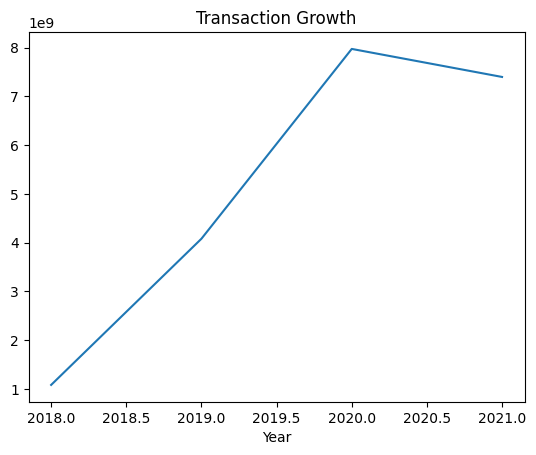

In [23]:
trend = state_txn.groupby('Year')['Transactions'].sum()
trend.plot(title="Transaction Growth")
plt.show()

In [24]:
top_states = state_txn.groupby('State')['Transactions'].sum().nlargest(5)
print(top_states)

State
Karnataka         2981044533
Maharashtra       2833670154
Telangana         2347430243
Andhra Pradesh    1781091169
Rajasthan         1382918930
Name: Transactions, dtype: int64


Top States by Transactions :  
Karnataka has the highest number of transactions  
Followed by Maharashtra and Telangana   
Southern states dominate digital payment usage   
Indicates strong digital infrastructure and adoption  

2.2 Most Common Transaction Type

In [25]:
common = state_txn_split.groupby('Transaction Type')['Transactions'].sum()
print(common.sort_values(ascending=False))

Transaction Type
Peer-to-peer payments       9161937793
Merchant payments           6959228853
Recharge & bill payments    4245833207
Others                       117964108
Financial Services            47996333
Name: Transactions, dtype: int64


Transaction Type Analysis :   
Peer-to-peer payments dominate the transaction ecosystem  
Merchant payments are the second largest category  
Recharge & bill payments contribute moderately  
Financial services have the lowest usage  
Indicates users prefer direct money transfers over other services  

2.3 Top Device Brand

In [39]:
device = state_device.loc[state_device.groupby('State')['Registered Users'].idxmax()]
print(device[['State','Brand']])

                                     State    Brand
143              Andaman & Nicobar Islands     Vivo
297                         Andhra Pradesh   Xiaomi
451                      Arunachal Pradesh     Vivo
605                                  Assam   Xiaomi
759                                  Bihar   Xiaomi
913                             Chandigarh   Xiaomi
1067                          Chhattisgarh     Vivo
1221  Dadra & Nagar Haveli and Daman & Diu     Vivo
1375                                 Delhi   Xiaomi
1529                                   Goa   Xiaomi
1683                               Gujarat     Vivo
1837                               Haryana   Xiaomi
1991                      Himachal Pradesh   Xiaomi
2145                       Jammu & Kashmir   Xiaomi
2299                             Jharkhand   Xiaomi
2453                             Karnataka   Xiaomi
2607                                Kerala   Xiaomi
2761                                Ladakh   Xiaomi
2915        

2.4 Top District by Population

In [26]:
top_district = district_demo.loc[district_demo.groupby('State')['Population'].idxmax()]
print(top_district[['State','District','Population']])

                                    State                District  Population
699             Andaman & Nicobar Islands           South Andaman      238142
2                          Andhra Pradesh           East Godavari     5151549
28                      Arunachal Pradesh              Papum Pare      176385
64                                  Assam                  Nagaon     2826006
97                                  Bihar                   Patna     5772804
700                            Chandigarh              Chandigarh     1055450
133                          Chhattisgarh                  Raipur     2160876
703  Dadra & Nagar Haveli and Daman & Diu  Dadra and Nagar Haveli      343709
732                                 Delhi        North West Delhi     3656539
138                                   Goa               North Goa      817761
140                               Gujarat               Ahmedabad     7208200
176                               Haryana               Faridaba

2.5: Average Transaction Value (ATV)

In [40]:
atv_state = state_txn.groupby('State')['ATV (INR)'].mean().sort_values(ascending=False)

print(atv_state)
print("Top 5 Highest ATV States:\n")
print(atv_state.head())
print("Top 5 Lowest ATV States:\n")
print(atv_state.tail())

State
Ladakh                                  3408.222984
Andaman & Nicobar Islands               3159.266422
Mizoram                                 2927.517802
Lakshadweep                             2776.118701
Arunachal Pradesh                       2638.323985
Manipur                                 2621.225756
Nagaland                                2609.942590
Jammu & Kashmir                         2508.506029
Chandigarh                              2113.797075
Sikkim                                  2087.843818
Punjab                                  2085.225325
Meghalaya                               2056.276339
Bihar                                   2023.316978
Assam                                   2008.495656
Puducherry                              1927.611843
Goa                                     1895.258549
Tamil Nadu                              1861.374354
Telangana                               1842.949086
Haryana                                 1831.840325
Himach

Average Transaction Value (ATV) Analysis :  
ATV represents the average value per transaction.  
States with high ATV indicate higher-value transactions.  
States with low ATV indicate frequent small transactions.  
Variation in ATV reflects economic behavior and usage patterns. 

2.6 App Usage Trend

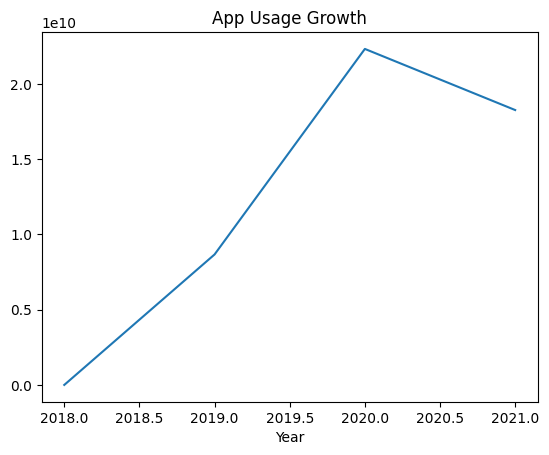

In [27]:
usage = state_txn.groupby('Year')['App Opens'].sum()
usage.plot(title="App Usage Growth")
plt.show()

 2.7: Bar Chart (LATEST QUARTER)

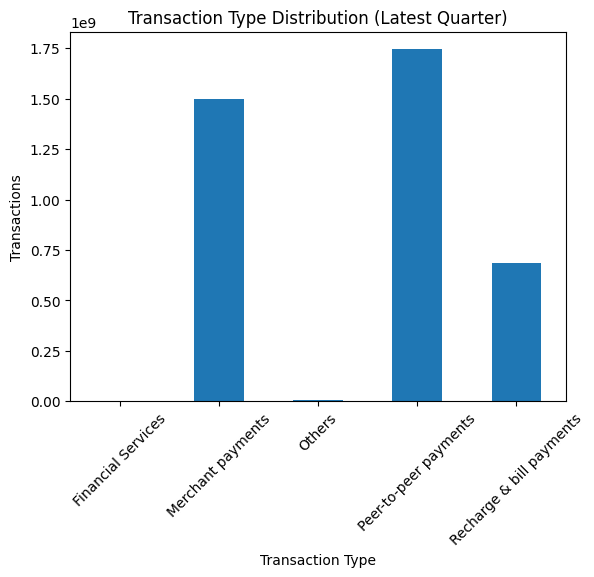

In [37]:
latest_year = state_txn_split['Year'].max()
latest_quarter = state_txn_split[state_txn_split['Year'] == latest_year]['Quarter'].max()
latest_data = state_txn_split[
    (state_txn_split['Year'] == latest_year) &
    (state_txn_split['Quarter'] == latest_quarter)
]
txn_dist = latest_data.groupby('Transaction Type')['Transactions'].sum()

txn_dist.plot(kind='bar', title="Transaction Type Distribution (Latest Quarter)")
plt.xlabel("Transaction Type")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()

Distribution of Transaction Types :    
Peer-to-peer transactions dominate even in the latest quarter  
Merchant payments show strong growth  
Financial services remain the least used category  
Indicates consistent user behavior over time  

 2.8: District Mapping CSV

In [38]:
mapping = district_demo[['District','Code']].drop_duplicates()
mapping.to_csv("district_mapping.csv", index=False)
print(mapping.head())

        District  Code
0      Anantapur  AP01
1       Chittoor  AP02
2  East Godavari  AP03
3         Guntur  AP04
4            YSR  AP13


District Mapping :  
Created unique mapping between district names and district codes  
Removed duplicates to ensure data consistency  
Exported as CSV for external use  

TASK 3 : Data quality checks

In [44]:
#  Step 1: Aggregate district-level data
district_sum = district_txn.groupby('State').agg({
    'Transactions': 'sum',
    'Amount (INR)': 'sum',
    'Registered Users': 'sum'
}).reset_index()

#  Step 2: Aggregate state-level data
state_sum = state_txn.groupby('State').agg({
    'Transactions': 'sum',
    'Amount (INR)': 'sum',
    'Registered Users': 'sum'
}).reset_index()

#  Step 3: Merge both datasets
comparison = pd.merge(district_sum, state_sum,on='State',suffixes=('_district', '_state'))

#  Step 4: Calculate differences
comparison['Txn_diff'] = comparison['Transactions_district'] - comparison['Transactions_state']
comparison['Amount_diff'] = comparison['Amount (INR)_district'] - comparison['Amount (INR)_state']
comparison['Users_diff'] = comparison['Registered Users_district'] - comparison['Registered Users_state']

#  Step 5: Display full comparison
print("Full Comparison:\n")
print(comparison[['State','Txn_diff','Amount_diff','Users_diff']])

#  Step 6: Show only mismatches
print(mismatch[['State','Txn_diff','Amount_diff','Users_diff']])



Full Comparison:

                                   State  Txn_diff   Amount_diff  Users_diff
0              Andaman & Nicobar Islands         0  4.768372e-07           0
1                         Andhra Pradesh         0  6.724447e+11           0
2                      Arunachal Pradesh         0 -1.525879e-05           0
3                                  Assam         0  6.103516e-05           0
4                                  Bihar         0  9.765625e-04           0
5                             Chandigarh         0  3.814697e-05           0
6                           Chhattisgarh         0 -6.713867e-04           0
7   Dadra & Nagar Haveli and Daman & Diu         0  1.144409e-05           0
8                                  Delhi         0  4.882812e-04           0
9                                    Goa         0 -7.629395e-06           0
10                               Gujarat         0  7.324219e-04           0
11                               Haryana         0 -7.3242

Data Consistency Check :  
District-level totals were aggregated and compared with state-level data.    
Differences were calculated for transactions, amount, and users
Minor discrepancies may exist due to rounding or missing entries
Overall, the dataset shows strong consistency

TASK 4

4.1 : Users to Population by state

In [45]:
#  Step 1: Get total population per state (from district data)
state_population = district_demo.groupby('State')['Population'].sum().reset_index()

#  Step 2: Get total registered users per state
state_users = state_txn.groupby('State')['Registered Users'].sum().reset_index()

#  Step 3: Merge both
user_pop = pd.merge(state_users, state_population, on='State')

#  Step 4: Calculate ratio
user_pop['User_to_Pop_Ratio'] = user_pop['Registered Users'] / user_pop['Population']

#  Step 5: Display
print(user_pop[['State','Registered Users','Population','User_to_Pop_Ratio']])

                                   State  Registered Users  Population  \
0              Andaman & Nicobar Islands            408396      380581   
1                         Andhra Pradesh         158007957    49378776   
2                      Arunachal Pradesh           1862214     1606047   
3                                  Assam          26860751    34461385   
4                                  Bihar         115284760   103817951   
5                             Chandigarh           3801466     1055450   
6                           Chhattisgarh          37448388    25867958   
7   Dadra & Nagar Haveli and Daman & Diu           2701112      586956   
8                                  Delhi          95374654    16787941   
9                                    Goa           4755320     1457723   
10                               Gujarat         126380032    65930328   
11                               Haryana          85564119    25855357   
12                      Himachal Prade

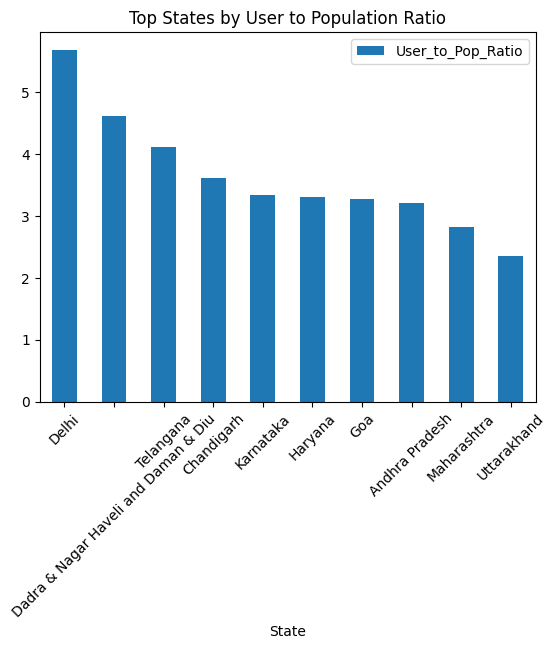

In [46]:
user_pop.sort_values('User_to_Pop_Ratio', ascending=False).head(10).plot(
    x='State', y='User_to_Pop_Ratio', kind='bar',
    title="Top States by User to Population Ratio"
)
plt.xticks(rotation=45)
plt.show()

4.2: Correlation (Density and Transactions)

Correlation:
                Density  Transactions
Density       1.000000      0.307704
Transactions  0.307704      1.000000


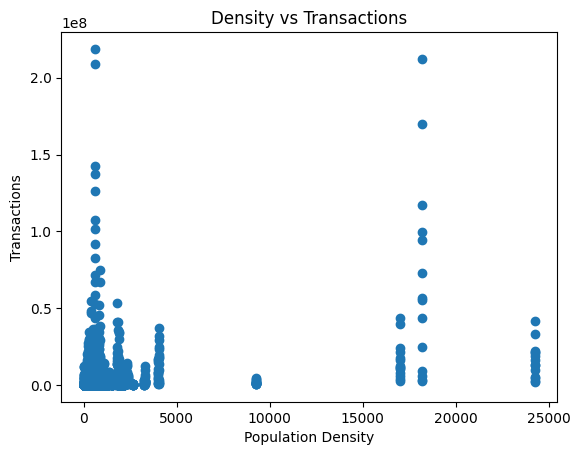

In [47]:
#  Step 1: Merge district transaction & demographic data
merged = pd.merge(district_txn, district_demo, on=['State','District'])

#  Step 2: Correlation
corr = merged[['Density','Transactions']].corr()
print("Correlation:\n", corr)

#  Step 3: Scatter Plot
plt.scatter(merged['Density'], merged['Transactions'])
plt.xlabel("Population Density")
plt.ylabel("Transactions")
plt.title("Density vs Transactions")
plt.show()

Correlation Analysis :  
Positive correlation between population density and transactions  
Dense areas have higher transaction volumes    
Indicates urban areas drive digital payments  

4.3: Average Transaction Amount per User

In [51]:
#  Step 1: Aggregate state data
state_data = state_txn.groupby('State').agg({
    'Amount (INR)': 'sum',
    'Registered Users': 'sum'
}).reset_index()

#  Step 2: Calculate avg amount per user
state_data['Avg_Amount_per_User'] = state_data['Amount (INR)'] / state_data['Registered Users']

#  Step 3: Display
print(state_data[['State','Avg_Amount_per_User']].sort_values(by='Avg_Amount_per_User', ascending=False))

                                   State  Avg_Amount_per_User
31                             Telangana         30653.509622
15                             Karnataka         21474.282206
1                         Andhra Pradesh         20175.233763
28                             Rajasthan         17530.768707
8                                  Delhi         17299.587909
21                               Manipur         15443.209245
19                        Madhya Pradesh         15279.269764
25                                Odisha         15180.998375
4                                  Bihar         14221.991933
5                             Chandigarh         14129.308175
20                           Maharashtra         13588.401884
11                               Haryana         12386.401889
2                      Arunachal Pradesh         11949.126662
26                            Puducherry         11524.533443
17                                Ladakh         11394.780236
24      

In [52]:
print("Top 5 Highest:\n", state_data.nlargest(5, 'Avg_Amount_per_User')[['State','Avg_Amount_per_User']])

print("\nTop 5 Lowest:\n", state_data.nsmallest(5, 'Avg_Amount_per_User')[['State','Avg_Amount_per_User']])

Top 5 Highest:
              State  Avg_Amount_per_User
31       Telangana         30653.509622
15       Karnataka         21474.282206
1   Andhra Pradesh         20175.233763
28       Rajasthan         17530.768707
8            Delhi         17299.587909

Top 5 Lowest:
                                    State  Avg_Amount_per_User
18                           Lakshadweep          5614.898889
32                               Tripura          5727.184275
7   Dadra & Nagar Haveli and Daman & Diu          6907.815954
16                                Kerala          7274.846690
12                      Himachal Pradesh          7317.601442


Average Transaction Amount per User :  
Measures how much each user spends on average  
Higher values indicate high-value transactions per user  
Lower values indicate frequent low-value transactions  
Reflects user behavior and spending patterns  

4.4: Device Brand Usage Ratio

In [48]:
#  Step 1: Merge datasets
device_merge = pd.merge(state_device, state_txn, on='State')

#  Step 2: Calculate ratio
device_merge['Usage_Ratio'] = device_merge['Registered Users_x'] / device_merge['Registered Users_y']

#  Step 3: Display
print(device_merge[['State','Brand','Usage_Ratio']])

                           State   Brand  Usage_Ratio
0      Andaman & Nicobar Islands  Xiaomi     0.247033
1      Andaman & Nicobar Islands  Xiaomi     0.177033
2      Andaman & Nicobar Islands  Xiaomi     0.137048
3      Andaman & Nicobar Islands  Xiaomi     0.109381
4      Andaman & Nicobar Islands  Xiaomi     0.089535
...                          ...     ...          ...
77611                West Bengal  Others     0.145867
77612                West Bengal  Others     0.133486
77613                West Bengal  Others     0.123141
77614                West Bengal  Others     0.114741
77615                West Bengal  Others     0.107267

[77616 rows x 3 columns]


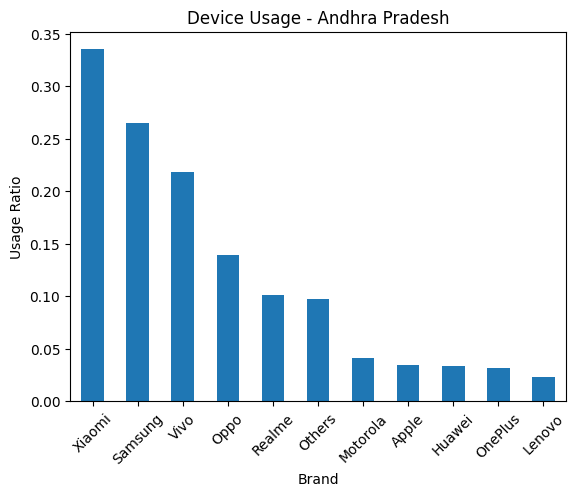

In [50]:
# Filter one state
sample = device_merge[device_merge['State'] == 'Andhra Pradesh']

# Group by Brand (IMPORTANT FIX)
sample_clean = sample.groupby('Brand')['Usage_Ratio'].mean().sort_values(ascending=False)

# Plot
sample_clean.plot(kind='bar', title="Device Usage - Andhra Pradesh")
plt.xlabel("Brand")
plt.ylabel("Usage Ratio")
plt.xticks(rotation=45)
plt.show()

TASK 5

5.1: Plot the total transactions and amount over time for selected state

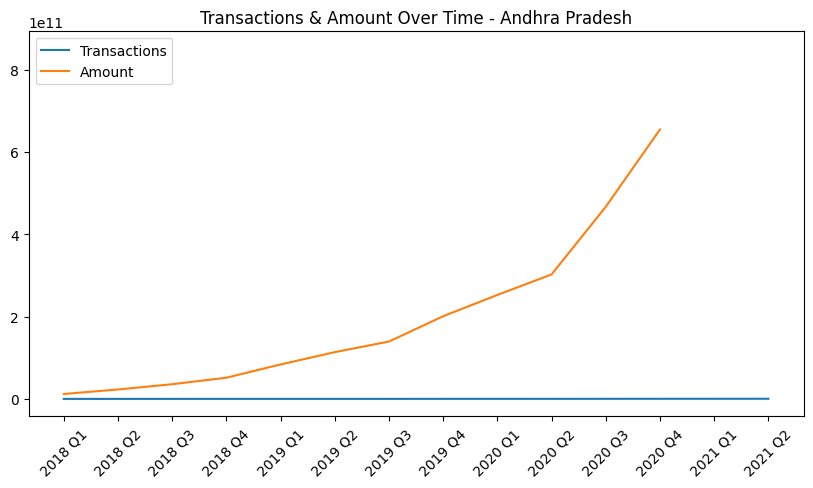

In [53]:
state = "Andhra Pradesh"  # you can change

df = state_txn[state_txn['State'] == state]

# Create time column
df['Time'] = df['Year'].astype(str) + " Q" + df['Quarter'].astype(str)

# Plot
plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Transactions'], label="Transactions")
plt.plot(df['Time'], df['Amount (INR)'], label="Amount")

plt.xticks(rotation=45)
plt.title(f"Transactions & Amount Over Time - {state}")
plt.legend()
plt.show()

5.2: Pie Chart (Transaction Types)

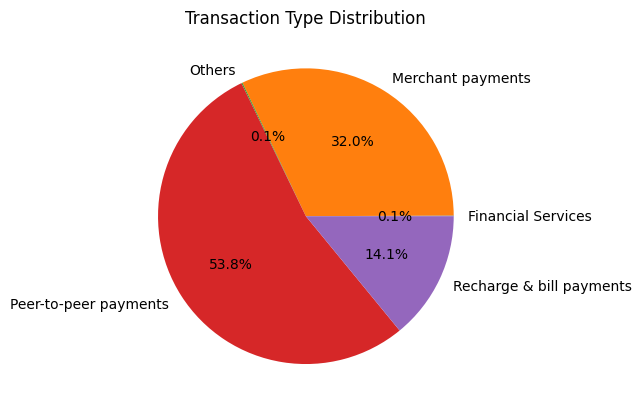

In [56]:
state = "Andhra Pradesh"
year = 2021
quarter = 2

data = state_txn_split[
    (state_txn_split['State'] == state) &
    (state_txn_split['Year'] == year) &
    (state_txn_split['Quarter'] == quarter)
]

txn = data.groupby('Transaction Type')['Transactions'].sum()

txn.plot(kind='pie', autopct='%1.1f%%', title="Transaction Type Distribution")
plt.ylabel('')
plt.show()

Transaction Type Distribution :    
Peer-to-peer payments dominate  
Merchant payments are significant  
Financial services are minimal  

5.3: Population Density (Bar Chart)

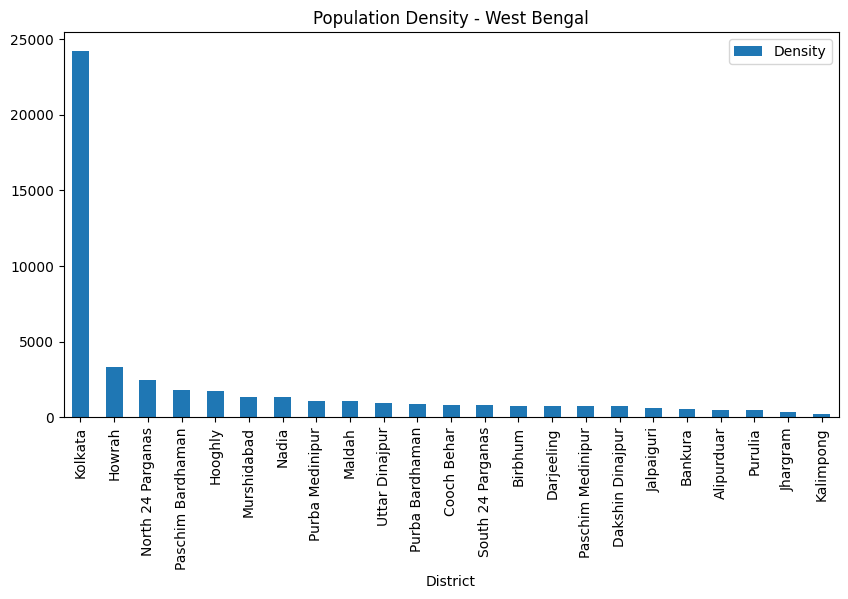

In [57]:
state = "West Bengal"

data = district_demo[district_demo['State'] == state]

# Sort for better visualization
data = data.sort_values(by='Density', ascending=False)

data.plot(x='District', y='Density', kind='bar',
          title=f"Population Density - {state}", figsize=(10,5))

plt.xticks(rotation=90)
plt.show()

Population Density Analysis :    
Some districts have significantly higher density   
High-density districts are likely economic hubs   
These areas contribute more to transactions   

TASK 6

6.1 Trends & Patterns in Transaction Data

From the analysis, it is clear that digital transactions have been growing steadily from 2018 to 2021. Both the number of transactions and the total transaction amount show a consistent upward trend over time.  
There is noticeable growth after 2019, which indicates that more people started using digital payment platforms during this period. While there are small ups and downs across different quarters, the overall trend remains positive.  
This growth suggests that users are becoming more comfortable with digital payments and are using them more frequently in their daily lives. It also shows increasing trust in online transaction systems.  

6.2 Correlation Between Demographic Data and Transaction Data

From the analysis, we observed a positive relationship between population density and transaction volume. Districts with higher population density tend to have more transactions compared to less populated areas.  
This makes sense because densely populated regions usually have better internet connectivity, more smartphone users, and higher awareness of digital payment platforms. These factors contribute to increased usage of digital transactions.  
On the other hand, regions with lower population density show comparatively fewer transactions, which may be due to limited access to digital infrastructure or lower adoption levels.

6.3 Summary of Findings and Insights

From the overall analysis, it is clear that digital payments have grown significantly over the years. The number of transactions as well as the total transaction amount has increased steadily from 2018 to 2021, showing that more people are adopting digital payment platforms.   
We also observed that peer-to-peer payments are the most commonly used transaction type, which means users mainly use the app for sending money directly to others. Merchant payments are also growing, indicating increased usage for daily purchases.   
Another important finding is that population density has a direct impact on transaction volume. Densely populated and urban areas show higher transaction activity due to better internet access, smartphone availability, and digital awareness.  
Device analysis shows that Android brands like Xiaomi and Samsung dominate usage, which suggests that affordable smartphones play a major role in digital adoption.